First 5 rows:
    customer_id  customer_age customer_income home_ownership  \
0          1.0            22           59000           RENT   
1          2.0            21            9600            OWN   
2          3.0            25            9600       MORTGAGE   
3          4.0            23           65500           RENT   
4          5.0            24           54400           RENT   

   employment_duration loan_intent loan_grade   loan_amnt  loan_int_rate  \
0                123.0    PERSONAL          C  £35,000.00          16.02   
1                  5.0   EDUCATION          A   £1,000.00          11.14   
2                  1.0     MEDICAL          B   £5,500.00          12.87   
3                  4.0     MEDICAL          B  £35,000.00          15.23   
4                  8.0     MEDICAL          B  £35,000.00          14.27   

   term_years historical_default  cred_hist_length Current_loan_status  
0          10                  Y                 3             DEFAULT  
1  

C:\Users\Natasha\AppData\Local\Temp\ipykernel_2240\1761758197.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  mydataset.fillna(method='ffill', inplace=True)  # Fill missing values (NaN) using the value above (forward fill)


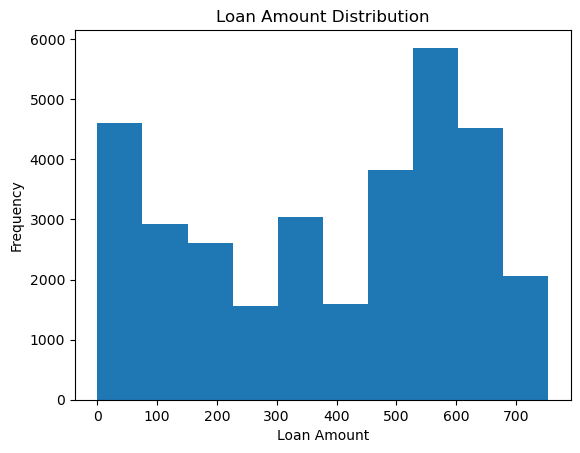


Accuracy: 0.8297023626879411

Confusion Matrix:
 [[ 545  831]
 [ 279 4863]]


C:\Users\Natasha\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [2]:

# Import libraries for data handling and visualization
import pandas as pd                 # For loading and manipulating data
import matplotlib.pyplot as plt     # For creating plots and visualizations

# Import libraries for Machine Learning
from sklearn.model_selection import train_test_split  # To split dataset into training and testing sets
from sklearn.linear_model import LogisticRegression   # Logistic Regression model for binary classification
from sklearn.metrics import accuracy_score, confusion_matrix  # For evaluating model performance
from sklearn.preprocessing import LabelEncoder        # To convert text columns into numeric values

# Step 1: Load dataset
mydataset = pd.read_csv("C:\\Users\\dell\\Downloads\\LoanDataset - LoansDatasest.csv")  # Load the CSV file "loan.csv" into a pandas DataFrame called mydataset

# Step 2: Show basic info
print("First 5 rows:\n", mydataset.head())           # Display the first 5 rows to see the data structure
print("\nMissing values:\n", mydataset.isnull().sum())  # Count missing values in each column

# Step 3: Fill missing values
mydataset.fillna(method='ffill', inplace=True)  # Fill missing values (NaN) using the value above (forward fill)

# Step 4: Convert text columns to numbers
le = LabelEncoder()  # Create a LabelEncoder object to convert categorical text to numeric

for col in mydataset.columns:            # Loop through all columns
    if mydataset[col].dtype == 'object': # Check if column is of type 'object' (text)
        mydataset[col] = le.fit_transform(mydataset[col])  # Convert text to numeric values

# Step 5: Drop unnecessary column
if 'Loan_ID' in mydataset.columns:       # Check if 'Loan_ID' exists
    mydataset = mydataset.drop('Loan_ID', axis=1)  # Drop 'Loan_ID' because it's just an identifier

# Step 6: Visualization
plt.hist(mydataset['loan_amnt'])         # Plot a histogram of the 'LoanAmount' column
plt.title("Loan Amount Distribution")     # Add a title to the plot
plt.xlabel("Loan Amount")                 # Label X-axis
plt.ylabel("Frequency")                   # Label Y-axis
plt.show()                                # Display the plot

# Step 7: Define input (X) and output (y)
X = mydataset.drop('Current_loan_status', axis=1)  # Features (all columns except target)
y = mydataset['Current_loan_status']               # Target variable (Loan_Status)

# Step 8: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  # Split data: 80% train, 20% test, random_state ensures reproducibility
)

# Step 9: Train model
model = LogisticRegression(max_iter=1000)  # Create Logistic Regression model with max iterations 1000
model.fit(X_train, y_train)                # Train model on training data

# Step 10: Prediction
y_pred = model.predict(X_test)             # Predict loan status for test data

# Step 11: Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))        # Print model accuracy
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))  # Print confusion matrix for detailed evaluation

First 5 rows:
    RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0 

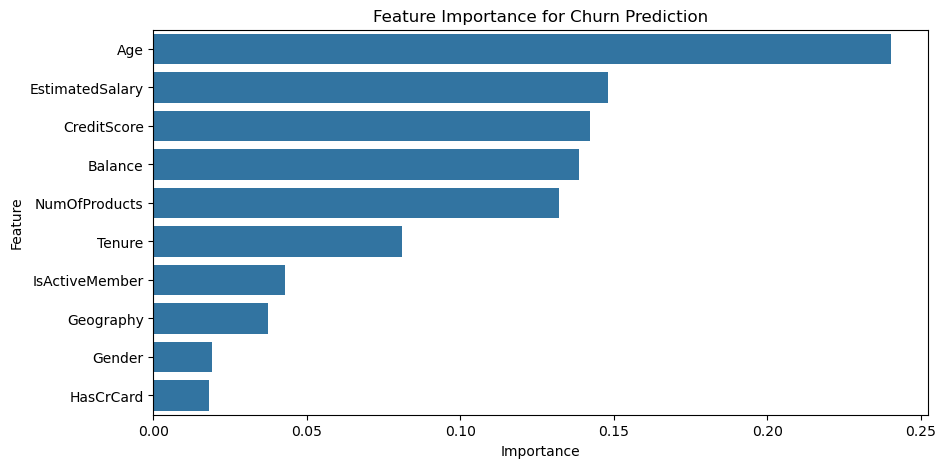

In [1]:
# ===============================
# CUSTOMER CHURN PREDICTION
# ===============================

# Import libraries for data handling and visualization
import pandas as pd                  # For loading, inspecting, and manipulating datasets
import matplotlib.pyplot as plt      # For plotting graphs
import seaborn as sns                # For advanced visualization (better styling for plots)

# Import machine learning tools
from sklearn.model_selection import train_test_split  # To split dataset into training and testing sets
from sklearn.preprocessing import LabelEncoder        # To convert categorical text into numeric values
from sklearn.ensemble import RandomForestClassifier   # Random Forest model for classification
from sklearn.metrics import accuracy_score, confusion_matrix  # For evaluating model performance

# Step 1: Load dataset
churn = pd.read_csv("C:\\Users\\dell\\Downloads\\Churn_Modelling.csv")  
# Load the CSV file into a pandas DataFrame called 'churn'

# Step 2: Check dataset
print("First 5 rows:\n", churn.head())                # Display first 5 rows to understand dataset structure
print("\nMissing values:\n", churn.isnull().sum())    # Count missing values in each column

# Step 3: Drop unnecessary columns
churn = churn.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)  
# Remove columns that are just identifiers and do not help prediction

# Step 4: Encode categorical columns automatically
le = LabelEncoder()                    # Create a LabelEncoder object to convert text to numeric
for col in ['Geography', 'Gender']:    # Loop through categorical columns
    churn[col] = le.fit_transform(churn[col])  
    # Converts text values (like 'Male', 'Female', 'France', 'Spain') to numeric codes

# Step 5: Define input (X) and target (y)
X = churn.drop('Exited', axis=1)      # Features: all columns except target 'Exited'
y = churn['Exited']                    # Target: 0 = customer stayed, 1 = customer exited

# Step 6: Split dataset into train & test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42  
    # 80% training, 20% testing; random_state ensures reproducibility
)

# Step 7: Train model (Random Forest)
model = RandomForestClassifier(n_estimators=100, random_state=42)  
# Create Random Forest model with 100 trees
model.fit(X_train, y_train)  
# Train the model on the training data

# Step 8: Predict
y_pred = model.predict(X_test)  
# Predict whether customers will churn on the test data

# Step 9: Evaluate model
print("\nAccuracy:", accuracy_score(y_test, y_pred))  
# Calculate the accuracy: percentage of correct predictions
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))  
# Shows True Positives, True Negatives, False Positives, and False Negatives

# Step 10: Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,                  # Feature names
    'Importance': model.feature_importances_  # Importance score assigned by Random Forest
}).sort_values(by='Importance', ascending=False)  # Sort features by importance

print("\nFeature Importance:\n", importance)  
# Display which features are most influential in predicting churn

# Step 11: Visualize feature importance
plt.figure(figsize=(10,5))  
# Set the figure size for better visibility
sns.barplot(x='Importance', y='Feature', data=importance)  
# Create a horizontal bar chart to show feature importance
plt.title("Feature Importance for Churn Prediction")  
# Add a title to the plot
plt.show()  
# Display the plot